# CMS Range Accrual Pricer

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys

sys.path.insert(0, '.')

from yield_curve import CurveBuilder, InterpolationMethod
from monte_carlo import MonteCarloEngine, CMSRateSimulator, ModelParameters
from products import ProductFactory, RangeAccrualProduct
from risk_analytics import RiskAnalyzer, RiskMetrics
from visualization import Visualizer

%matplotlib inline
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


## Construction des courbes de taux

In [2]:
ois_curve, swap_curve = CurveBuilder.build_sample_curves()

print("Courbes construites :")
print(f"{ois_curve}")
print(f"{swap_curve}")

print("\nQuelques taux OIS :")
for tenor in [1.0, 5.0, 10.0]:
    rate = ois_curve.get_rate(tenor)
    df = ois_curve.get_discount_factor(tenor)
    print(f"  {tenor:4.0f}Y: {rate:6.2%}  (Discount Factor: {df:.6f})")

Courbes construites :
YieldCurve(name='OIS', points=10)
YieldCurve(name='Swap', points=10)

Quelques taux OIS :
     1Y:  2.35%  (Discount Factor: 0.976774)
     5Y:  3.10%  (Discount Factor: 0.856415)
    10Y:  3.40%  (Discount Factor: 0.711770)


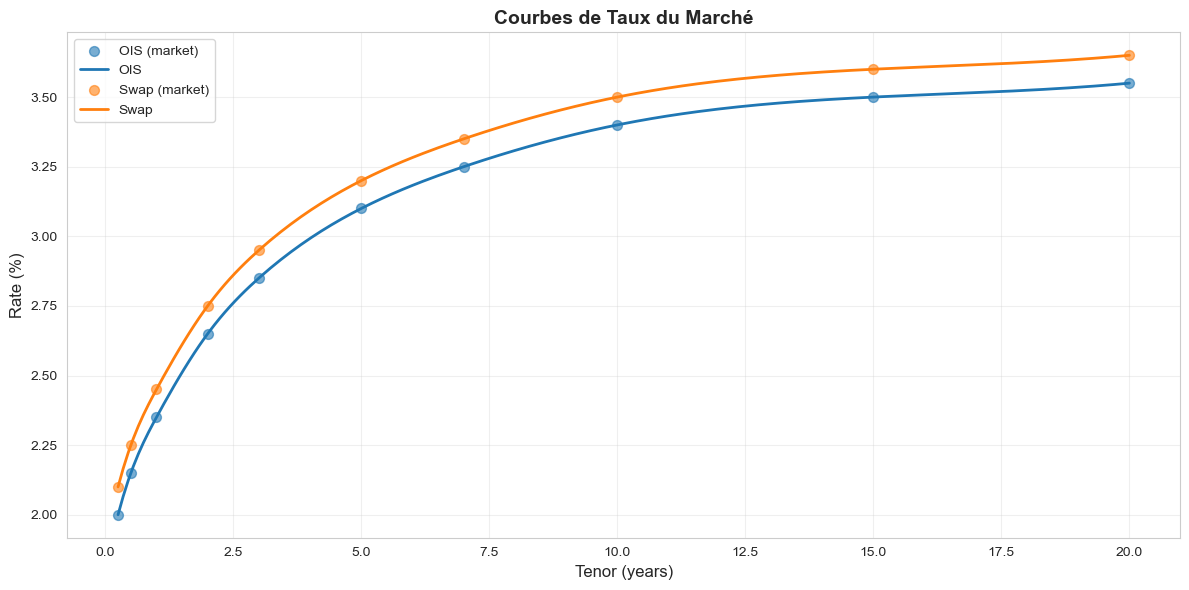

In [3]:

fig = Visualizer.plot_yield_curve(
    curves={'OIS': ois_curve, 'Swap': swap_curve},
    title="Courbes de Taux du Marché"
)
plt.show()

## Définition du produit CMS Range Accrual

In [4]:
product = ProductFactory.create_standard_range_accrual(
    notional=10_000_000,      # Notionnel : 10M€
    coupon_rate=0.06,         # Coupon : 6% par an
    range_lower=0.025,        # Borne basse : 2.5%
    range_upper=0.045,        # Borne haute : 4.5%
    maturity=5.0,             # Maturité : 5 ans
    cms_tenor=10.0            # CMS 10Y
)

print("Produit créé :")
print(product)
print("\nCaractéristiques :")
print(f"Paye {product.coupon_rate:.1%} si le CMS 10Y reste dans [{product.range_lower:.2%}, {product.range_upper:.2%}]")
print(f"Accrual linéaire basé sur le temps passé dans la range")
print(f"Maturité : {product.maturity} ans")

Produit créé :
RangeAccrual(Notional=10,000,000, Coupon=6.00%, Range=[2.50%, 4.50%], Maturity=5.0Y, CMS=10.0Y)

Caractéristiques :
Paye 6.0% si le CMS 10Y reste dans [2.50%, 4.50%]
Accrual linéaire basé sur le temps passé dans la range
Maturité : 5.0 ans


## Setup du modèle stochastique pour le CMS

In [5]:
params = ModelParameters(
    mean_reversion=0.08,      # Vitesse de retour à la moyenne : 8%
    volatility=0.018,         # Volatilité annuelle : 1.8%
    long_term_mean=0.033      # Moyenne long terme : 3.3%
)

initial_cms_rate = swap_curve.get_rate(product.cms_tenor)

print("Modèle stochastique configuré :")
print(f"Taux CMS 10Y initial : {initial_cms_rate:.2%}")
print(f"Mean reversion : {params.mean_reversion:.1%}")
print(f"Volatilité : {params.volatility:.2%}")
print(f"Moyenne LT : {params.long_term_mean:.2%}")

simulator = CMSRateSimulator(
    initial_rate=initial_cms_rate,
    parameters=params,
    random_seed=42
)

print("\nSimulateur prêt !")

Modèle stochastique configuré :
Taux CMS 10Y initial : 3.50%
Mean reversion : 8.0%
Volatilité : 1.80%
Moyenne LT : 3.30%

Simulateur prêt !


In [6]:
sample_paths = simulator.simulate_paths(n_paths=5, n_steps=100, time_horizon=5.0)

print("Test de simulation :")
print(f"{sample_paths.shape[0]} paths simulés")
print(f"{sample_paths.shape[1]} steps de temps")
print(f"Taux finaux : {[f'{r:.2%}' for r in sample_paths[:, -1]]}")

Test de simulation :
5 paths simulés
101 steps de temps
Taux finaux : ['1.76%', '5.81%', '0.01%', '8.60%', '3.35%']


## Pricing Monte Carlo

In [7]:
mc_engine = MonteCarloEngine(
    discount_curve=ois_curve,
    n_simulations=10_000,
    random_seed=42
)
payoff_fn = product.payoff_function()
mc_results = mc_engine.price_product(
    simulator=simulator,
    payoff_function=payoff_fn,
    maturity=product.maturity,
    n_steps=252 
)

print("\n" + "="*60)
print("RÉSULTATS DU PRICING".center(60))
print("="*60)
print(f"Prix:              ${mc_results['price']:>15,.2f}")
print(f"Erreur standard:   ${mc_results['std_error']:>15,.2f}")
print(f"IC 95%:            [${mc_results['price'] - 1.96*mc_results['std_error']:,.2f}, ${mc_results['price'] + 1.96*mc_results['std_error']:,.2f}]")
print(f"Discount Factor:    {mc_results['discount_factor']:>15.6f}")
print(f"Payoff moyen:      ${mc_results['avg_payoff']:>15,.2f}")
print(f"Std payoff:        ${mc_results['payoff_std']:>15,.2f}")
print("="*60)


                    RÉSULTATS DU PRICING                    
Prix:              $     954,820.17
Erreur standard:   $       4,929.38
IC 95%:            [$945,158.59, $964,481.75]
Discount Factor:           0.856415
Payoff moyen:      $   1,114,903.37
Std payoff:        $     575,582.76


## Visualisation des simulations

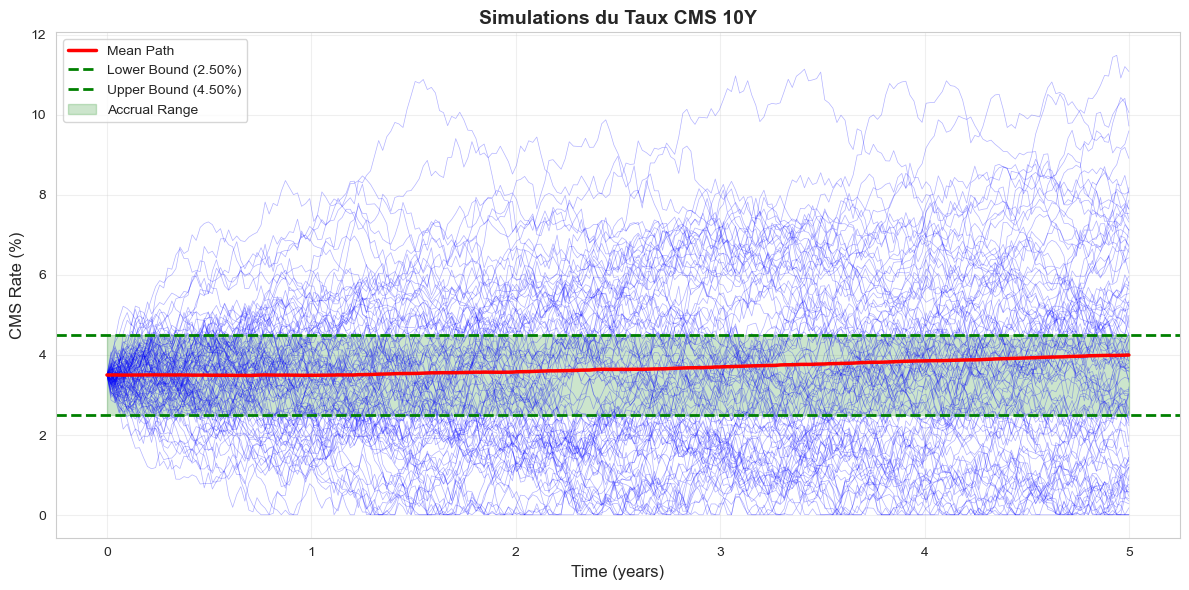

In [8]:
fig = Visualizer.plot_cms_paths(
    paths=mc_results['paths'],
    product=product,
    n_display=100,
    title="Simulations du Taux CMS 10Y"
)
plt.show()

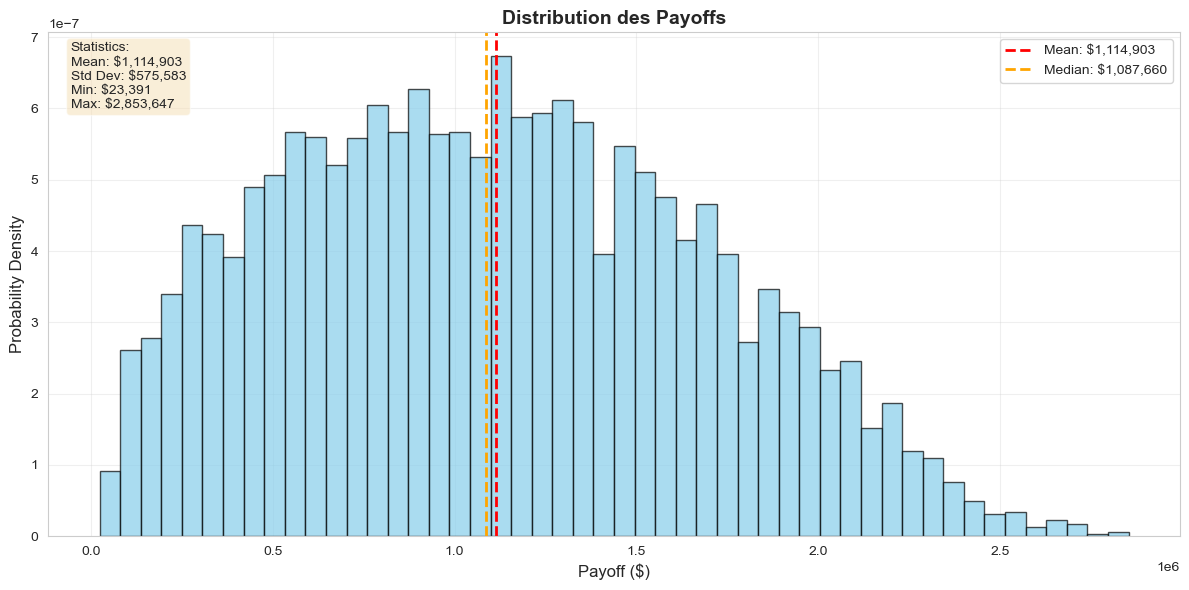

In [9]:
fig = Visualizer.plot_payoff_distribution(
    payoffs=mc_results['payoffs'],
    product=product,
    title="Distribution des Payoffs"
)
plt.show()

## Analyse des risques (DV01, Slope, Gamma)

In [11]:
risk_analyzer = RiskAnalyzer(
    product=product,
    discount_curve=ois_curve,
    simulator=simulator,
    mc_engine=mc_engine
)

In [12]:
# DV01
dv01_results = risk_analyzer.calculate_dv01()

print("\nDV01 (Dollar Value of 1bp):")
print(f"  • DV01 total:      ${dv01_results['dv01']:>12,.2f} par bp")
print(f"  • Par $1M:         ${dv01_results['dv01_per_million']:>12,.2f} par bp")
print(f"  • Prix de base:    ${dv01_results['base_price']:>12,.2f}")
print(f"  • Prix +1bp:       ${dv01_results['up_price']:>12,.2f}")
print(f"  • Prix -1bp:       ${dv01_results['down_price']:>12,.2f}")


DV01 (Dollar Value of 1bp):
  • DV01 total:      $26,341,336.49 par bp
  • Par $1M:         $2,634,133.65 par bp
  • Prix de base:    $  972,834.96
  • Prix +1bp:       $  956,746.52
  • Prix -1bp:       $  962,014.79


In [15]:
# Slope risk
slope_results = risk_analyzer.calculate_slope_risk()

print("\nSlope Risk (Steepening):")
print(f"Slope risk:      ${slope_results['slope_risk']:>12,.2f}")
print(f"Par bp:          ${slope_results['slope_risk_per_bp']:>12,.2f}")
print(f"Pivot:           {slope_results['pivot_tenor']}Y")


Slope Risk (Steepening):
Slope risk:      $    2,951.72
Par bp:          $29,517,179.82
Pivot:           5.0Y


In [16]:
# Gamma 
gamma_results = risk_analyzer.calculate_gamma()

print("\nGamma (Convexité):")
print(f"Gamma:           {gamma_results['gamma']:>12,.2f}")
print(f"Convexité:       {gamma_results['convexity_pct']:>12.4f}%")


Gamma (Convexité):
Gamma:           -934,276,940,429.05
Convexité:       -97325444.5786%


## Analyse de scénarios

In [18]:
scenarios = [
    {'name': 'Base', 'shift': 0.0000},
    {'name': '+25bp', 'shift': 0.0025},
    {'name': '+50bp', 'shift': 0.0050},
    {'name': '+100bp', 'shift': 0.0100},
    {'name': '-25bp', 'shift': -0.0025},
    {'name': '-50bp', 'shift': -0.0050},
]

scenario_results = risk_analyzer.scenario_pnl(scenarios, n_steps=252)

print("\n" + "="*70)
print("ANALYSE DE SCÉNARIOS P&L".center(70))
print("="*70)
print(f"{'Scénario':<12} {'Prix':>15} {'P&L':>15} {'P&L %':>12}")
print("-"*70)

for scenario in scenarios:
    name = scenario['name']
    result = scenario_results[name]
    print(
        f"{name:<12} "
        f"${result['price']:>14,.2f} "
        f"${result['pnl']:>14,.2f} "
        f"{result['pnl_pct']:>11.2f}%"
    )
print("="*70)


                       ANALYSE DE SCÉNARIOS P&L                       
Scénario                Prix             P&L        P&L %
----------------------------------------------------------------------
Base         $    965,277.89 $     10,232.36        1.07%
+25bp        $    944,216.42 $    -10,829.11       -1.13%
+50bp        $    922,120.62 $    -32,924.91       -3.45%
+100bp       $    914,206.79 $    -40,838.74       -4.28%
-25bp        $    968,930.74 $     13,885.21        1.45%
-50bp        $    986,062.15 $     31,016.62        3.25%


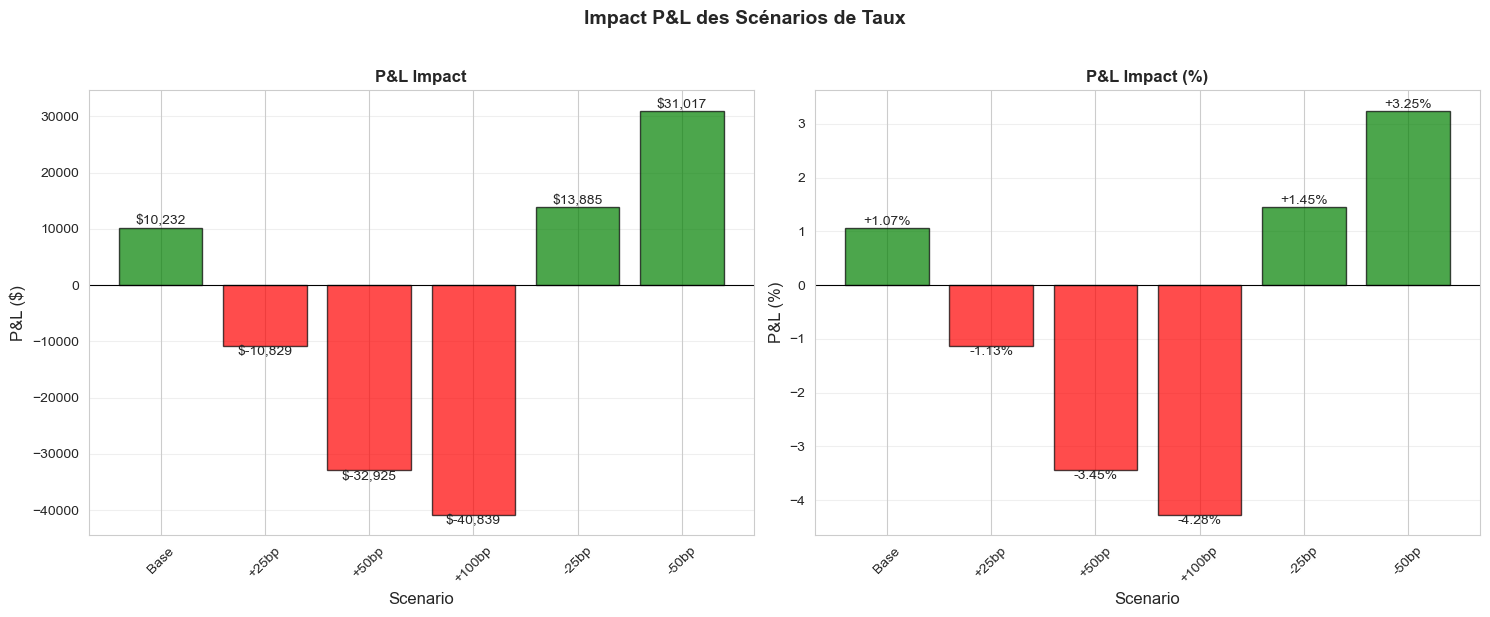

In [19]:

fig = Visualizer.plot_scenario_pnl(
    scenario_results=scenario_results,
    title="Impact P&L des Scénarios de Taux"
)
plt.show()

## Key Rate Durations (Ladder Risk)

In [21]:
key_tenors = [1.0, 2.0, 5.0, 7.0, 10.0, 15.0]

ladder_risks = risk_analyzer.ladder_risk(key_tenors, n_steps=100)

print("\n Key Rate Durations:")
for tenor, risk in ladder_risks.items():
    print(f"  {tenor:5.0f}Y: ${risk:>12,.2f}")


 Key Rate Durations:
      1Y: $48,698,928.75
      2Y: $50,103,946.78
      5Y: $56,895,787.12
      7Y: $68,243,733.23
     10Y: $-14,727,599.78
     15Y: $61,996,420.88


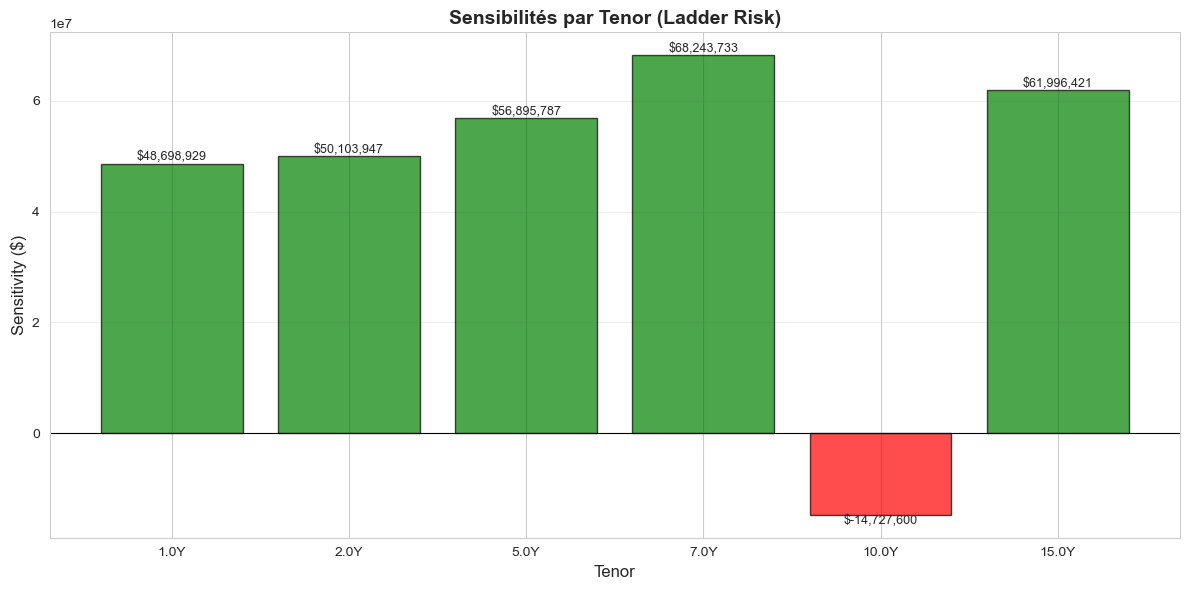

In [24]:
fig = Visualizer.plot_risk_ladder(
    ladder_risks=ladder_risks,
    title="Sensibilités par Tenor (Ladder Risk)"
)
plt.show()

## Dashboard 

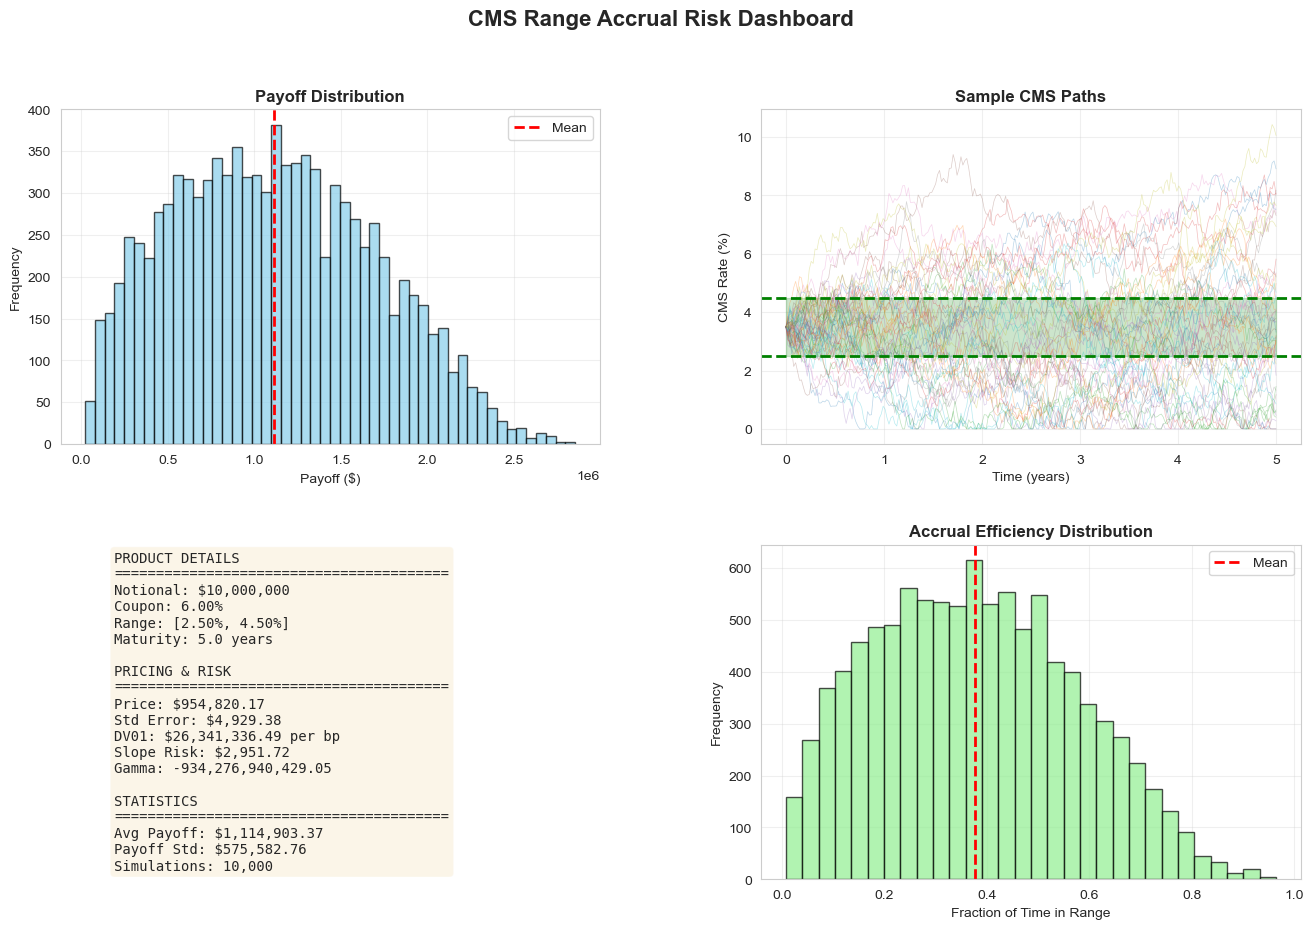

In [26]:

risk_metrics = RiskMetrics(
    dv01=dv01_results['dv01'],
    slope_risk=slope_results['slope_risk'],
    gamma=gamma_results['gamma']
)

fig = Visualizer.create_risk_dashboard(
    product=product,
    mc_results=mc_results,
    risk_metrics=risk_metrics
)
plt.show()

## 🎯 Résumé Final

In [28]:
print("\n" + "="*70)
print("RÉSUMÉ DE L'ANALYSE".center(70))
print("="*70)

print("\nPRODUIT:")
print(f"Notionnel:       ${product.notional:>12,}")
print(f"Coupon:          {product.coupon_rate:>13.2%}")
print(f"Range:           [{product.range_lower:.2%}, {product.range_upper:.2%}]")
print(f"Maturité:        {product.maturity:>12.0f} ans")

print("\nPRICING:")
print(f"Prix:            ${mc_results['price']:>12,.2f}")
print(f"Std Error:       ${mc_results['std_error']:>12,.2f}")
print(f"Simulations:     {mc_results['n_simulations']:>12,}")

print("\nRISQUES:")
print(f"DV01:            ${dv01_results['dv01']:>12,.2f} /bp")
print(f"Slope Risk:      ${slope_results['slope_risk']:>12,.2f}")
print(f"Gamma:           {gamma_results['gamma']:>12,.2f}")


                         RÉSUMÉ DE L'ANALYSE                          

PRODUIT:
Notionnel:       $  10,000,000
Coupon:                  6.00%
Range:           [2.50%, 4.50%]
Maturité:                   5 ans

PRICING:
Prix:            $  954,820.17
Std Error:       $    4,929.38
Simulations:           10,000

RISQUES:
DV01:            $26,341,336.49 /bp
Slope Risk:      $    2,951.72
Gamma:           -934,276,940,429.05
